In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
class Dataset:
    def __init__(self, func, x_range=(-5, 5)):
        self.func = func
        self.x_min, self.x_max = x_range

    def sample(self, n_samples=200, mode="random"):
        if mode == "random":
            x = np.random.uniform(self.x_min, self.x_max, (n_samples, 1))
        else:
            x = np.linspace(self.x_min, self.x_max, n_samples).reshape(-1, 1)

        y = self.func(x)
        return x, y


# 设定目标函数
def target_function(x):
    return np.sin(x) + 0.3 * x

In [ ]:
class ReLUNetwork:
    def __init__(self, input_dim=1, hidden_dim=64, output_dim=1, lr=0.01):
        self.lr = lr

        # 初始化
        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2. / input_dim)
        self.b1 = np.zeros((1, hidden_dim))

        self.W2 = np.random.randn(hidden_dim, hidden_dim) * np.sqrt(2. / hidden_dim)
        self.b2 = np.zeros((1, hidden_dim))

        self.W3 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2. / hidden_dim)
        self.b3 = np.zeros((1, output_dim))

    # 激活函数
    def relu(self, x):
        return np.maximum(0, x)

    def relu_grad(self, x):
        return (x > 0).astype(float)

    # 前向传播
    def forward(self, x):
        self.z1 = x @ self.W1 + self.b1
        self.a1 = self.relu(self.z1)

        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.relu(self.z2)

        self.y_pred = self.a2 @ self.W3 + self.b3
        return self.y_pred

    # 损失函数
    def compute_loss(self, y_pred, y_true):
        return np.mean((y_pred - y_true) ** 2)

    # 反向传播
    def backward(self, x, y_true):
        n = y_true.shape[0]

        dL_dy = 2 * (self.y_pred - y_true) / n

        # 第3层
        dW3 = self.a2.T @ dL_dy
        db3 = np.sum(dL_dy, axis=0, keepdims=True)

        da2 = dL_dy @ self.W3.T

        # 第2层
        dz2 = da2 * self.relu_grad(self.z2)
        dW2 = self.a1.T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)

        da1 = dz2 @ self.W2.T

        # 第1层
        dz1 = da1 * self.relu_grad(self.z1)
        dW1 = x.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)

        # 更新参数
        self.W3 -= self.lr * dW3
        self.b3 -= self.lr * db3

        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    # 训练
    def train(self, x, y, epochs=2000, verbose=True):
        loss_list = []

        for epoch in range(epochs):
            y_pred = self.forward(x)
            loss = self.compute_loss(y_pred, y)
            loss_list.append(loss)

            self.backward(x, y)

            if verbose and epoch % 200 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.6f}")

        return loss_list

    # 预测
    def predict(self, x):
        return self.forward(x)

In [7]:
np.random.seed(42)

# 数据集
dataset = Dataset(target_function)

x_train, y_train = dataset.sample(200, mode="random")
x_test, y_test = dataset.sample(200, mode="uniform")

# 模型
model = ReLUNetwork(hidden_dim=64, lr=0.01)

# 训练
loss_list = model.train(x_train, y_train, epochs=2000)

Epoch 0, Loss: 5.968100
Epoch 200, Loss: 0.108447
Epoch 400, Loss: 0.064503
Epoch 600, Loss: 0.047006
Epoch 800, Loss: 0.033974
Epoch 1000, Loss: 0.023112
Epoch 1200, Loss: 0.016116
Epoch 1400, Loss: 0.010430
Epoch 1600, Loss: 0.006733
Epoch 1800, Loss: 0.005370


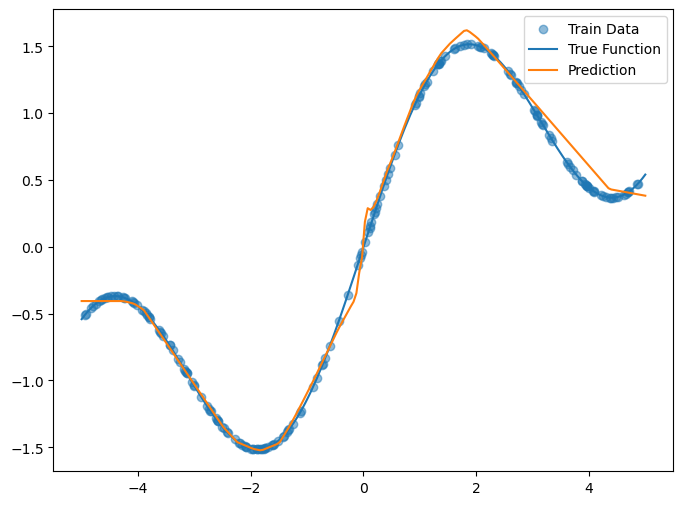

In [21]:
# 预测结果可视化

y_pred = model.predict(x_test)

plt.figure(figsize=(8,6))
plt.scatter(x_train, y_train, label="Train Data", alpha=0.5)
plt.plot(x_test, y_test, label="True Function")
plt.plot(x_test, y_pred, label="Prediction")
plt.legend()
plt.savefig("function_approximation_numpy_class.png")
plt.show()
